In [ ]:
# Sequential_workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [21]:
# Step-1: define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [22]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    
    return state

In [23]:
# Step-2: Define your graph
graph = StateGraph(BMIState)

# Step-3: Add Nodes to your graph
# (Node_name, function_name)
graph.add_node('Calculate_BMI', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# Step-4: Add Edges to your Graph
graph.add_edge(START, 'Calculate_BMI')
graph.add_edge('Calculate_BMI', 'label_bmi')
graph.add_edge('Calculate_BMI', END)

# Step-5: Compile the graph
workflow = graph.compile()

In [24]:
inital_state = {'weight_kg': 80, 'height_m':1.73}
# Step-6: Execute the graph
final_state = workflow.invoke(inital_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


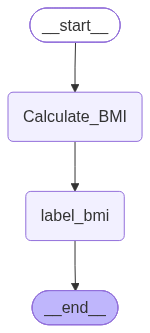

In [25]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())